# Multiple Linear Regression

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

***Dataset***

In [3]:
# feature colomn (Year of Exp, PS Skill, Pause Time, CGPA)
x = np.array([
    [1, 4, 1.5, 3.8],
    [3, 6, 1.0, 3.1],
    [4, 7, 0.8, 3.9],
    [5, 8, 0.4, 3.4],
    [7, 9, 0.2, 2.8]
])

# target colomn (Salary)
y = np.array([45,  76.55,  92.35, 107.9 , 128. ])

Text(0, 0.5, 'Salary')

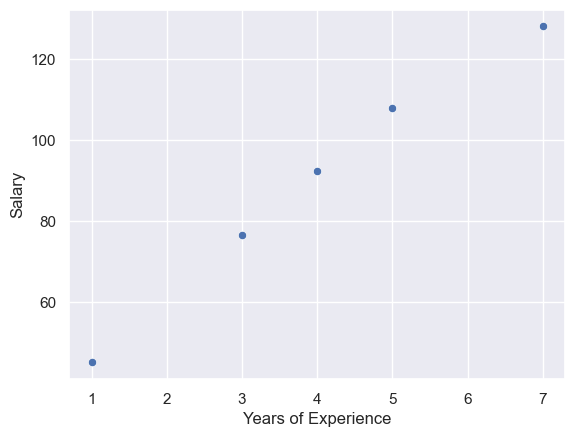

In [4]:
sns.scatterplot(x=x[:, 0:1].ravel(), y=y)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")

Text(0, 0.5, 'Salary')

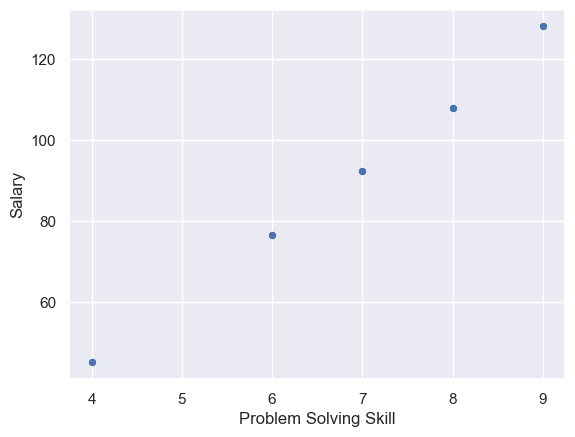

In [5]:
sns.scatterplot(x=x[:, 1:2].ravel(), y=y)

plt.xlabel("Problem Solving Skill")
plt.ylabel("Salary")

Text(0, 0.5, 'Salary')

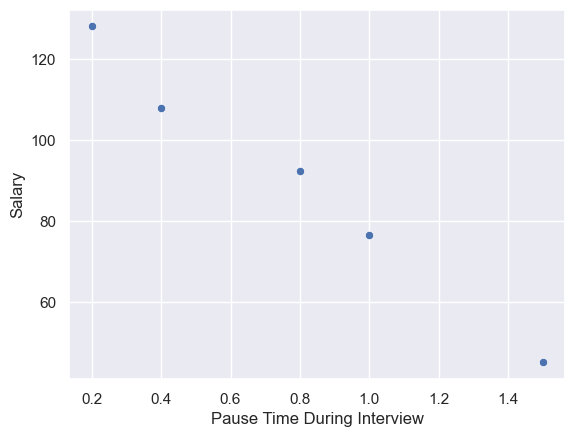

In [6]:
sns.scatterplot(x=x[:, 2:3].ravel(), y=y)

plt.xlabel("Pause Time During Interview")
plt.ylabel("Salary")

Text(0, 0.5, 'Salary')

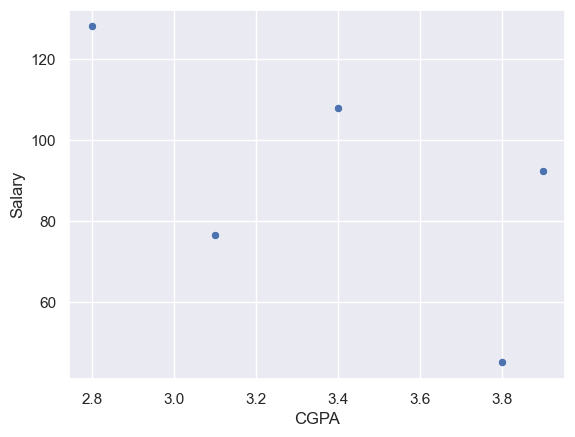

In [7]:
sns.scatterplot(x=x[:, 3:].ravel(), y=y)

plt.xlabel("CGPA")
plt.ylabel("Salary")

***Prediction Function***

In [8]:
def make_prediction(X, W, b):
    m = X.shape[0] # number of datapoints in the input array

    prediction_list = np.zeros((m,))

    for i in range(m):
        prediction_list[i] = np.dot(W, X[i]) + b # W -> weights vector, X -> features vector

    return prediction_list

***Initialization*** (Sample)

In [9]:
m = x.shape[0] # row
n = x.shape[1] # column

w_init = np.ones((n,))
b_init = 1.0

make_prediction(x, w_init, b_init)

array([11.3, 14.1, 16.7, 17.8, 20. ])

***Cost Function***

In [10]:
def compute_cost(X, y, W, b):
    
    m = X.shape[0] # number of datapoint

    prediction_list = make_prediction(X, W, b)    

    error = prediction_list - y # error = ȳ - y
    error_squared = error ** 2 
    cost = np.sum(error_squared)
    
    mse = cost /(2 * m) # mean square error

    print(f"Prediction Output: {prediction_list}")
    print(f"Actual Output: {y}\n")
    print(f"Error List: {error}")
    print(f"Error Squared List: {error_squared}\n")
    print(f"Total Cost: {cost}")    

    return mse

***Initial Cost*** (Sample)

In [11]:
msc = compute_cost(x, y, w_init, b_init)
print(f"Mean Square Error: {msc}")

Prediction Output: [11.3 14.1 16.7 17.8 20. ]
Actual Output: [ 45.    76.55  92.35 107.9  128.  ]

Error List: [ -33.7   -62.45  -75.65  -90.1  -108.  ]
Error Squared List: [ 1135.69    3900.0025  5722.9225  8118.01   11664.    ]

Total Cost: 30540.625
Mean Square Error: 3054.0625


***Gradient Function***

In [12]:
def calculate_gradint(X, y, W, b):

    m = X.shape[0] # row
    n = X.shape[1] # column

    dj_dw = np.zeros((n,)) # dj/dw = 1 / m * ∑ (ȳ - y) * x
    dj_db = 0.0 # dj/db = 1 / m * ∑ (ȳ - y)
    

    for i in range(m):
        ȳ = np.dot(W, X[i]) + b # prediction
        error = ȳ - y[i]

        for j in range(n):
            dj_dw[j] = dj_dw[j] + (error * X[i, j]) # weight

        dj_db = dj_db + error # bias

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db
    

***Calculate Gradient***

In [13]:
weight, bias = calculate_gradint(x, y, w_init, b_init)
print(f"dj/dw: {weight}")
print(f"dj/db: {bias}")

dj/dw: [-346.03  -546.37   -46.232 -245.086]
dj/db: -73.98


***Cost Function***

In [14]:
def compute_cost(X, y, W, b):
    
    m = X.shape[0] # number of datapoint

    prediction_list = make_prediction(X, W, b)    

    error = prediction_list - y # error = ȳ - y
    error_squared = error ** 2 
    cost = np.sum(error_squared)
    
    mse = cost /(2 * m) # mean square error  

    return mse

***Gradient Descent Algorithm***

In [15]:
def gradient_descent(x, y, w_input, b_input, max_itr, alpha = 0.01):

    w = w_input
    b = b_input

    cost_memo = [] 
    iteration = []

    for i in range(max_itr):
        dj_dw, dj_db = calculate_gradint(x, y, w, b)

        # update
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(x, y, w, b) # J(w,b)= ∑ ​(ȳ − y) ^ 2
        
        cost_memo.append(cost)
        iteration.append(i)

        if (i % 100) == 0:
            print(f"For i={i} th")
            print(f"Weight : {w}")
            print(f"Bias : {b:0.4f}")
            print(f"Gradient (∂J/∂w) : {dj_dw}")
            print(f"Gradient (∂J/∂b) : {dj_db:0.4f}")
            print(f"Cost : {cost:0.4f}")
            print("______________")

    return w, b, cost_memo, iteration


In [16]:
w_init = np.zeros((n,))
b_init = 0.0

weight, bias, cost_memo, iter = gradient_descent(x, y, w_input=w_init, b_input=b_init, max_itr=10000, alpha=0.01)

For i=0 th
Weight : [4.1591  6.6019  0.57338 2.98746]
Bias : 0.8996
Gradient (∂J/∂w) : [-415.91  -660.19   -57.338 -298.746]
Gradient (∂J/∂b) : -89.9600
Cost : 189.6679
______________
For i=100 th
Weight : [ 6.90361644  8.31342922 -0.46201001  1.64454729]
Bias : 0.6776
Gradient (∂J/∂w) : [-0.29378157 -0.0680317   0.27356437  0.45990364]
Gradient (∂J/∂b) : 0.0968
Cost : 0.3121
______________
For i=200 th
Weight : [ 6.95883505  8.38046769 -0.58216959  1.46014189]
Bias : 0.6398
Gradient (∂J/∂w) : [ 0.04465576 -0.06609397  0.05528392  0.06810245]
Gradient (∂J/∂b) : 0.0129
Cost : 0.2320
______________
For i=300 th
Weight : [ 6.89826719  8.44562879 -0.62615086  1.41199782]
Bias : 0.6311
Gradient (∂J/∂w) : [ 0.06672251 -0.06425669  0.03893763  0.03943169]
Gradient (∂J/∂b) : 0.0069
Cost : 0.2197
______________
For i=400 th
Weight : [ 6.83131441  8.50898093 -0.66382302  1.37448196]
Bias : 0.6246
Gradient (∂J/∂w) : [ 0.06652053 -0.0624739   0.03686148  0.0364083 ]
Gradient (∂J/∂b) : 0.0064
Cost 

***Final Weight & Bias***

In [17]:
print(f"Weight: {weight}")
print(f"Bias: {bias}")

Weight: [ 4.61393057 10.59029188 -1.90706886  0.21187133]
Bias: 0.2599175916962207


***Testing***

In [18]:
# salary for a new employee
# ȳ = w * x + b
x_test = np.array([[2, 10, 1.5, 3.8]])
ȳ = make_prediction(x_test, weight, bias)

print(f"Salary for this employee: {ȳ[0]:.2f}")

Salary for this employee: 113.34


# Linear Regression Using Scikit Learn

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

***OLS Method*** (when dataset is small)

In [20]:
model1 = LinearRegression()

model1.fit(x, y)

weights = model1.coef_
bias = model1.intercept_

print(f"Weights: {weights}")
print(f"Bias: {bias}")

Weights: [ 4.23636364 11.90909091  1.54545455 -0.04545455]
Bias: -9.018181818181631


***SGD Regressor*** (when dataset is large)

In [24]:
model2 = SGDRegressor(penalty=None, max_iter=1000000, learning_rate="constant")

model2.fit(x, y)

weights = model1.coef_
bias = model1.intercept_

print(f"Weights: {weights}")
print(f"Bias: {bias}")

Weights: [ 4.23636364 11.90909091  1.54545455 -0.04545455]
Bias: -9.018181818181631
